# 基于Fourier Neural Operator的Burgers' equation求解

[![下载Notebook](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_notebook.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/master/mindflow/zh_cn/data_driven/mindspore_burgers_FNO1D.ipynb)&emsp;[![下载样例代码](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_download_code.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/master/mindflow/zh_cn/data_driven/mindspore_burgers_FNO1D.py)&emsp;[![查看源文件](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_source.png)](https://gitee.com/mindspore/docs/blob/master/docs/mindflow/docs/source_zh_cn/data_driven/burgers_FNO1D.ipynb)

## 概述

计算流体力学是21世纪流体力学领域的重要技术之一，其通过使用数值方法在计算机中对流体力学的控制方程进行求解，从而实现流动的分析、预测和控制。传统的有限元法（finite element method，FEM）和有限差分法（finite difference method，FDM）常用于复杂的仿真流程（物理建模、网格划分、数值离散、迭代求解等）和较高的计算成本，往往效率低下。因此，借助AI提升流体仿真效率是十分必要的。

近年来，随着神经网络的迅猛发展，为科学计算提供了新的范式。经典的神经网络是在有限维度的空间进行映射，只能学习与特定离散化相关的解。与经典神经网络不同，傅里叶神经算子（Fourier Neural Operator，FNO）是一种能够学习无限维函数空间映射的新型深度学习架构。该架构可直接学习从任意函数参数到解的映射，用于解决一类偏微分方程的求解问题，具有更强的泛化能力。更多信息可参考[Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/abs/2010.08895)。

本案例教程介绍利用傅里叶神经算子的1-d Burgers方程求解方法。

## 伯格斯方程（Burgers' equation）

一维伯格斯方程（1-d Burgers' equation）是一个非线性偏微分方程，具有广泛应用，包括一维粘性流体流动建模。它的形式如下：

$$
\partial_t u(x, t)+\partial_x (u^2(x, t)/2)=\nu \partial_{xx} u(x, t), \quad x \in(0,1), t \in(0, 1]
$$

$$
u(x, 0)=u_0(x), \quad x \in(0,1)
$$

其中$u$表示速度场，$u_0$表示初始条件，$\nu$表示粘度系数。


## 问题描述

本案例利用Fourier Neural Operator学习初始状态到下一时刻状态的映射，实现一维Burgers'方程的求解：

$$
u_0 \mapsto u(\cdot, 1)
$$

## 技术路径

MindFlow求解该问题的具体流程如下：

1. 创建数据集。
2. 构建模型。
3. 优化器与损失函数。
4. 模型训练。

## Fourier Neural Operator

Fourier Neural Operator模型构架如下图所示。图中$w_0(x)$表示初始涡度，通过Lifting Layer实现输入向量的高维映射，然后将映射结果作为Fourier Layer的输入，进行频域信息的非线性变换，最后由Decoding Layer将变换结果映射至最终的预测结果$w_1(x)$。

Lifting Layer、Fourier Layer以及Decoding Layer共同组成了Fourier Neural Operator。

![Fourier Neural Operator模型构架](images/FNO.png)

Fourier Layer网络结构如下图所示。图中V表示输入向量，上框表示向量经过傅里叶变换后，经过线性变换R，过滤高频信息，然后进行傅里叶逆变换；另一分支经过线性变换W，最后通过激活函数，得到Fourier Layer输出向量。

![Fourier Layer网络结构](images/FNO-2.png)

In [ ]:
import sys
import os
project_root = os.path.abspath("../../../../..")
sys.path.append(project_root)

In [2]:
import os
import time
import numpy as np

from mindspore.amp import DynamicLossScaler, auto_mixed_precision, all_finite
from mindspore import context, nn, Tensor, set_seed, ops, data_sink, jit, save_checkpoint
from mindspore import dtype as mstype
from mindscience import FNO1D, RelativeRMSELoss, load_yaml_config, get_warmup_cosine_annealing_lr
from mindscience.pde import UnsteadyFlowWithLoss

/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


下述`src`包可以在[applications/data_driven/burgers/fno1d/src](https://gitee.com/mindspore/mindscience/tree/master/MindFlow/applications/data_driven/burgers/fno1d/src)下载。

In [3]:
from src import create_training_dataset, visual

set_seed(0)
np.random.seed(0)

context.set_context(mode=context.GRAPH_MODE, device_target="Ascend", device_id=0,max_device_memory="32GB")
use_ascend = context.get_context(attr_key='device_target') == "Ascend"

从`config`中获得模型、数据、优化器的参数。

In [4]:
config = load_yaml_config('./configs/fno1d.yaml')
data_params = config["data"]
model_params = config["model"]
optimizer_params = config["optimizer"]

## 创建数据集

下载训练与测试数据集: [data_driven/burgers/fno1d/dataset](https://download.mindspore.cn/mindscience/mindflow/dataset/applications/data_driven/burgers/dataset/)。

本案例根据Zongyi Li在 [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/pdf/2010.08895.pdf) 一文中对数据集的设置生成训练数据集与测试数据集。具体设置如下：
基于周期性边界，生成满足如下分布的初始条件$u_0(x)$：

$$
u_0 \sim \mu, \mu=\mathcal{N}\left(0,625(-\Delta+25 I)^{-2}\right)
$$

本案例选取粘度系数$\nu=0.1$，并使用分步法求解方程，其中热方程部分在傅里叶空间中精确求解，然后使用前向欧拉方法求解非线性部分。训练集样本量为1000个，测试集样本量为200个。


In [5]:
# create training dataset
train_dataset = create_training_dataset(data_params, model_params, shuffle=True)

# create test dataset
test_input, test_label = np.load(os.path.join(data_params["root_dir"], "test/inputs.npy")), \
                         np.load(os.path.join(data_params["root_dir"], "test/label.npy"))
test_input = Tensor(np.expand_dims(test_input, -2), mstype.float32)
test_label = Tensor(np.expand_dims(test_label, -2), mstype.float32)

Data preparation finished
input_path:  (1000, 1024, 1)
label_path:  (1000, 1024)


## 构建模型

网络由1层Lifting layer、1层Decoding layer以及多层Fourier Layer叠加组成：

- Lifting layer对应样例代码中`FNO1D.fc0`，将输出数据$x$映射至高维；

- 多层Fourier Layer的叠加对应样例代码中`FNO1D.fno_seq`，本案例采用离散傅里叶变换实现时域与频域的转换；

- Decoding layer对应代码中`FNO1D.fc1`与`FNO1D.fc2`，获得最终的预测值。

基于上述网络结构，进行模型初始化，其中模型参数可在[配置文件](https://gitee.com/mindspore/mindscience/blob/master/MindFlow/applications/data_driven/burgers/fno1d/configs/fno1d.yaml)中修改。

In [6]:
model = FNO1D(in_channels=model_params["in_channels"],
              out_channels=model_params["out_channels"],
              n_modes=model_params["modes"],
              resolutions=model_params["resolutions"],
              hidden_channels=model_params["hidden_channels"],
              n_layers=model_params["depths"],
              projection_channels=4*model_params["hidden_channels"],
              )
model_params_list = []
for k, v in model_params.items():
    model_params_list.append(f"{k}:{v}")
model_name = "_".join(model_params_list)
print(model_name)

name:FNO1D_in_channels:1_out_channels:1_modes:16_resolutions:1024_hidden_channels:64_depths:4


## 优化器与损失函数

使用相对均方根误差作为网络训练损失函数：

In [7]:
steps_per_epoch = train_dataset.get_dataset_size()
lr = get_warmup_cosine_annealing_lr(lr_init=optimizer_params["learning_rate"],
                                    last_epoch=optimizer_params["epochs"],
                                    steps_per_epoch=steps_per_epoch,
                                    warmup_epochs=1)
optimizer = nn.Adam(model.trainable_params(), learning_rate=Tensor(lr))

if use_ascend:
    from mindspore.amp import DynamicLossScaler, auto_mixed_precision, all_finite
    loss_scaler = DynamicLossScaler(1024, 2, 100)
    auto_mixed_precision(model, 'O3')
else:
    loss_scaler = None

## 模型训练

使用 **MindSpore version >= 2.0.0**, 我们可以使用函数式编程来训练神经网络。 `MindFlow` 为非稳态问题 `UnsteadyFlowWithLoss` 提供了一个训练接口，用于模型训练和评估.

In [ ]:
problem = UnsteadyFlowWithLoss(model, loss_fn=RelativeRMSELoss(), data_format="NHWTC")

summary_dir = os.path.join(config["summary"]["summary_dir"], model_name)
print(summary_dir)

def forward_fn(data, label):
    loss = problem.get_loss(data, label)
    if use_ascend:
        loss = loss_scaler.scale(loss)
    return loss

grad_fn = ops.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=False)

@jit
def train_step(data, label):
    loss, grads = grad_fn(data, label)
    if use_ascend:
        loss = loss_scaler.unscale(loss)
        if all_finite(grads):
            grads = loss_scaler.unscale(grads)
    loss = ops.depend(loss, optimizer(grads))
    return loss

sink_process = data_sink(train_step, train_dataset, 1)
ckpt_dir = os.path.join(summary_dir, "ckpt")
if not os.path.exists(ckpt_dir):
    os.makedirs(ckpt_dir)

for epoch in range(1, optimizer_params["epochs"] + 1):
    model.set_train()
    local_time_beg = time.time()
    for _ in range(steps_per_epoch):
        cur_loss = sink_process()
    print(
        f"epoch: {epoch} train loss: {cur_loss.asnumpy():.8f}"\
        f" epoch time: {time.time() - local_time_beg:.2f}s"\
        f" step time: {(time.time() - local_time_beg)/steps_per_epoch:.4f}s")

    if epoch % config['summary']['test_interval'] == 0:
        model.set_train(False)
        print("================================Start Evaluation================================")
        rms_error = problem.get_loss(test_input, test_label)/test_input.shape[0]
        print(f"mean rms_error: {rms_error}")
        print("=================================End Evaluation=================================")
        save_checkpoint(model, os.path.join(ckpt_dir, model_params["name"] + '_epoch' + str(epoch)))

./summary/name:FNO1D_in_channels:1_out_channels:1_modes:16_resolutions:1024_hidden_channels:64_depths:4


[ERROR] CORE(11705,ffff9080b020,python):2025-11-21-12:39:59.699.170 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_11705/2488151560.py]
[ERROR] CORE(11705,ffff9080b020,python):2025-11-21-12:39:59.701.686 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_11705/2488151560.py]
[ERROR] CORE(11705,ffff9080b020,python):2025-11-21-12:39:59.701.740 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_11705/2488151560.py]
[ERROR] CORE(11705,ffff9080b020,python):2025-11-21-12:39:59.701.920 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_11705/2488151560.py]
[ERROR] CORE(11705,ffff9080b020,python):2025-11-21-12:39:59.701.969 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_11705/2488151560.py]


..epoch: 1 train loss: 0.23573753 epoch time: 19.21s step time: 0.1537s
epoch: 2 train loss: 0.21564198 epoch time: 2.06s step time: 0.0165s
epoch: 3 train loss: 0.22462566 epoch time: 2.08s step time: 0.0166s
epoch: 4 train loss: 0.19544056 epoch time: 2.10s step time: 0.0168s
epoch: 5 train loss: 0.17717326 epoch time: 2.09s step time: 0.0167s
epoch: 6 train loss: 0.32128695 epoch time: 2.07s step time: 0.0166s
epoch: 7 train loss: 0.14024872 epoch time: 2.06s step time: 0.0165s
epoch: 8 train loss: 0.26638049 epoch time: 2.06s step time: 0.0165s
epoch: 9 train loss: 0.10469551 epoch time: 2.09s step time: 0.0167s
epoch: 10 train loss: 0.13028814 epoch time: 2.08s step time: 0.0166s
================================Start Evaluation================================
mean rms_error: 0.020006742
=================================End Evaluation=================================
epoch: 11 train loss: 0.14310433 epoch time: 2.02s step time: 0.0161s
epoch: 12 train loss: 0.08992550 epoch time: 2

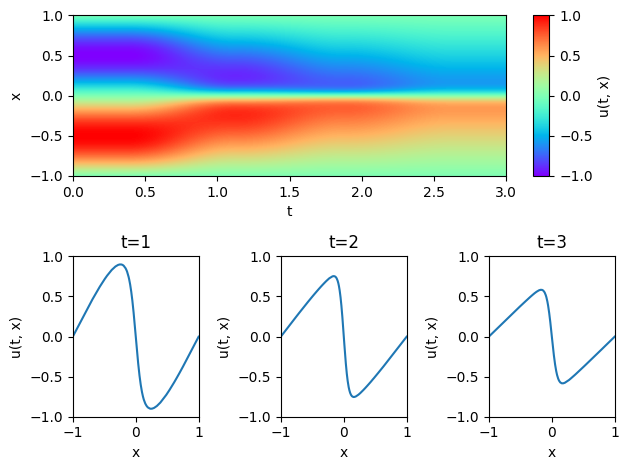

In [9]:
visual(model, epochs=optimizer_params["epochs"], resolution=model_params["resolutions"])